In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

BATCH_SIZE = 64
INPUT_SHAPE = (32, 32, 3)
NUM_CLASSES = 10

# Loading CIFAR-10 Dataset

In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2770s 16us/step


In [7]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


# Dataset Visualization

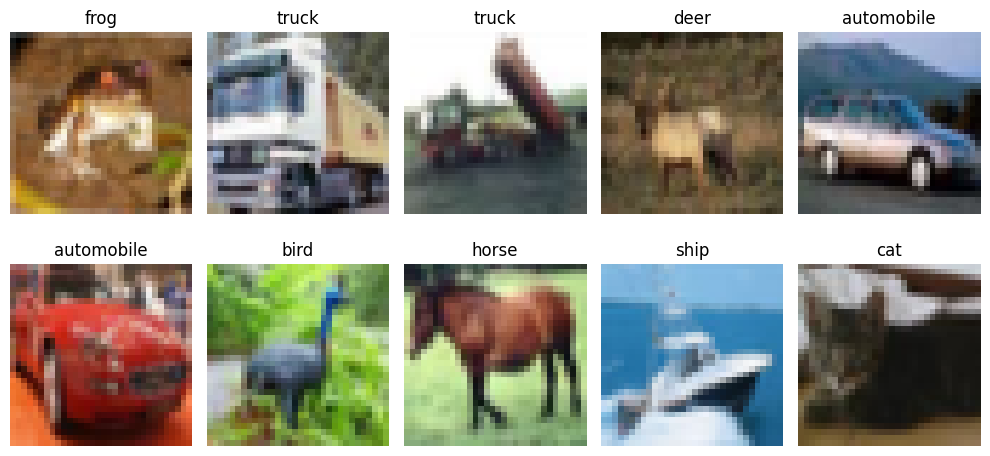

In [8]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

In [10]:
def compile_model(model):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def train_model(model, epochs, callbacks=None):
    return model.fit(
        x_train_norm,
        y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=2
    )


def evaluate_model(model, name):
    loss, acc = model.evaluate(
        x_test_norm,
        y_test,
        verbose=0
    )

    print(f"{name} Accuracy: {acc:.4f}")
    return loss, acc

# Baseline Artificial Neural Network (ANN)

In [11]:
def build_ann():
    return models.Sequential([
        layers.Flatten(input_shape=INPUT_SHAPE),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

# ANN Training and Evaluation

In [12]:
ann_model = compile_model(build_ann())

ann_history = train_model(
    ann_model,
    epochs=10
)

ann_loss, ann_acc = evaluate_model(
    ann_model,
    "ANN"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
704/704 - 8s - 11ms/step - accuracy: 0.2481 - loss: 2.0295 - val_accuracy: 0.3342 - val_loss: 1.8747
Epoch 2/10
704/704 - 3s - 4ms/step - accuracy: 0.3016 - loss: 1.9020 - val_accuracy: 0.3444 - val_loss: 1.8303
Epoch 3/10
704/704 - 3s - 4ms/step - accuracy: 0.3206 - loss: 1.8562 - val_accuracy: 0.3548 - val_loss: 1.8018
Epoch 4/10
704/704 - 2s - 3ms/step - accuracy: 0.3280 - loss: 1.8367 - val_accuracy: 0.3496 - val_loss: 1.7828
Epoch 5/10
704/704 - 2s - 3ms/step - accuracy: 0.3367 - loss: 1.8167 - val_accuracy: 0.3902 - val_loss: 1.7520
Epoch 6/10
704/704 - 2s - 3ms/step - accuracy: 0.3387 - loss: 1.8079 - val_accuracy: 0.3766 - val_loss: 1.7541
Epoch 7/10
704/704 - 3s - 4ms/step - accuracy: 0.3490 - loss: 1.7837 - val_accuracy: 0.3828 - val_loss: 1.7469
Epoch 8/10
704/704 - 5s - 7ms/step - accuracy: 0.3528 - loss: 1.7778 - val_accuracy: 0.3756 - val_loss: 1.7515
Epoch 9/10
704/704 - 2s - 3ms/step - accuracy: 0.3587 - loss: 1.7653 - val_accuracy: 0.3756 - val_loss: 1.7300


In [13]:
ann_model = compile_model(build_ann())

ann_history = train_model(
    ann_model,
    epochs=10
)

ann_loss, ann_acc = evaluate_model(
    ann_model,
    "ANN"
)

Epoch 1/10
704/704 - 7s - 10ms/step - accuracy: 0.2498 - loss: 2.0334 - val_accuracy: 0.3030 - val_loss: 1.8902
Epoch 2/10
704/704 - 2s - 3ms/step - accuracy: 0.3033 - loss: 1.9000 - val_accuracy: 0.3228 - val_loss: 1.8328
Epoch 3/10
704/704 - 3s - 4ms/step - accuracy: 0.3206 - loss: 1.8577 - val_accuracy: 0.3578 - val_loss: 1.7929
Epoch 4/10
704/704 - 2s - 3ms/step - accuracy: 0.3304 - loss: 1.8337 - val_accuracy: 0.3640 - val_loss: 1.7804
Epoch 5/10
704/704 - 2s - 3ms/step - accuracy: 0.3401 - loss: 1.8072 - val_accuracy: 0.3678 - val_loss: 1.7753
Epoch 6/10
704/704 - 3s - 4ms/step - accuracy: 0.3483 - loss: 1.7940 - val_accuracy: 0.3858 - val_loss: 1.7371
Epoch 7/10
704/704 - 2s - 3ms/step - accuracy: 0.3515 - loss: 1.7822 - val_accuracy: 0.3720 - val_loss: 1.7530
Epoch 8/10
704/704 - 3s - 4ms/step - accuracy: 0.3550 - loss: 1.7734 - val_accuracy: 0.3946 - val_loss: 1.7438
Epoch 9/10
704/704 - 2s - 3ms/step - accuracy: 0.3581 - loss: 1.7645 - val_accuracy: 0.3958 - val_loss: 1.7341


# Baseline Convolutional Neural Network (CNN)

In [14]:
def build_cnn():
    return models.Sequential([

        layers.Conv2D(
            32,
            (3,3),
            activation="relu",
            padding="same",
            input_shape=INPUT_SHAPE
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            (3,3),
            activation="relu",
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            128,
            (3,3),
            activation="relu",
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

# CNN Training and Evaluation

In [15]:
cnn_model = compile_model(build_cnn())

cnn_history = train_model(
    cnn_model,
    epochs=10
)

cnn_loss, cnn_acc = evaluate_model(
    cnn_model,
    "CNN"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 - 17s - 24ms/step - accuracy: 0.4416 - loss: 1.5555 - val_accuracy: 0.4852 - val_loss: 1.5273
Epoch 2/10
704/704 - 4s - 5ms/step - accuracy: 0.5878 - loss: 1.1605 - val_accuracy: 0.5292 - val_loss: 1.3399
Epoch 3/10
704/704 - 4s - 5ms/step - accuracy: 0.6523 - loss: 0.9913 - val_accuracy: 0.5976 - val_loss: 1.1557
Epoch 4/10
704/704 - 4s - 6ms/step - accuracy: 0.6982 - loss: 0.8605 - val_accuracy: 0.6966 - val_loss: 0.9043
Epoch 5/10
704/704 - 5s - 7ms/step - accuracy: 0.7292 - loss: 0.7708 - val_accuracy: 0.6846 - val_loss: 0.9893
Epoch 6/10
704/704 - 4s - 5ms/step - accuracy: 0.7595 - loss: 0.6873 - val_accuracy: 0.7096 - val_loss: 0.8529
Epoch 7/10
704/704 - 4s - 6ms/step - accuracy: 0.7819 - loss: 0.6210 - val_accuracy: 0.6362 - val_loss: 1.2003
Epoch 8/10
704/704 - 4s - 5ms/step - accuracy: 0.8011 - loss: 0.5608 - val_accuracy: 0.7400 - val_loss: 0.7734
Epoch 9/10
704/704 - 4s - 5ms/step - accuracy: 0.8202 - loss: 0.5093 - val_accuracy: 0.7394 - val_loss: 0.8848

# ANN vs CNN Validation Accuracy Comparison

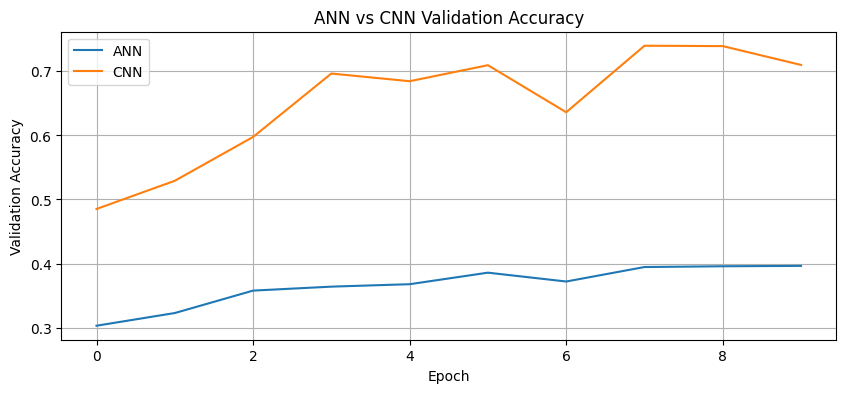

In [16]:
plt.figure(figsize=(10,4))

plt.plot(
    ann_history.history["val_accuracy"],
    label="ANN"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="CNN"
)

plt.title("ANN vs CNN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

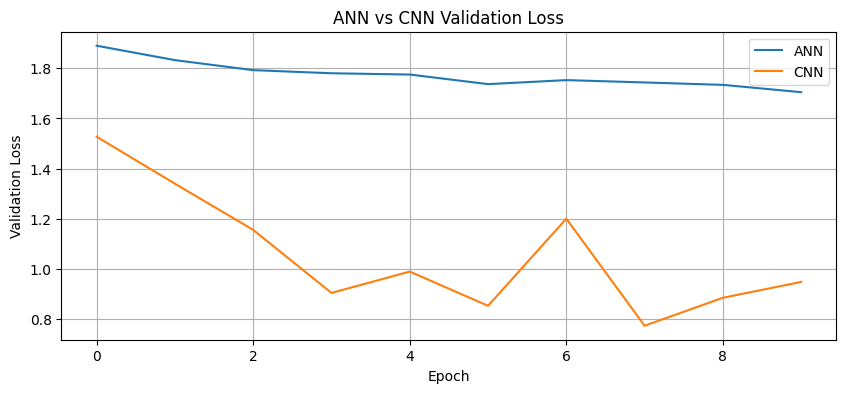

In [17]:
plt.figure(figsize=(10,4))

plt.plot(
    ann_history.history["val_loss"],
    label="ANN"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="CNN"
)

plt.title("ANN vs CNN Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [19]:
def build_improved_ann():
    return models.Sequential([
        layers.Flatten(input_shape=INPUT_SHAPE),

        layers.Dense(1024, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

# Improved Artificial Neural Network

In [20]:
improved_ann = compile_model(
    build_improved_ann()
)

improved_ann_history = train_model(
    improved_ann,
    epochs=20,
    callbacks=[early_stop]
)

improved_ann_loss, improved_ann_acc = evaluate_model(
    improved_ann,
    "Improved ANN"
)

Epoch 1/20
704/704 - 10s - 14ms/step - accuracy: 0.2078 - loss: 2.1006 - val_accuracy: 0.2732 - val_loss: 1.9969
Epoch 2/20
704/704 - 3s - 4ms/step - accuracy: 0.2456 - loss: 1.9932 - val_accuracy: 0.2886 - val_loss: 1.9381
Epoch 3/20
704/704 - 3s - 4ms/step - accuracy: 0.2683 - loss: 1.9528 - val_accuracy: 0.3196 - val_loss: 1.8928
Epoch 4/20
704/704 - 3s - 4ms/step - accuracy: 0.2813 - loss: 1.9252 - val_accuracy: 0.3264 - val_loss: 1.8785
Epoch 5/20
704/704 - 3s - 5ms/step - accuracy: 0.2929 - loss: 1.9038 - val_accuracy: 0.3096 - val_loss: 1.8921
Epoch 6/20
704/704 - 3s - 4ms/step - accuracy: 0.2980 - loss: 1.8909 - val_accuracy: 0.3400 - val_loss: 1.8475
Epoch 7/20
704/704 - 3s - 4ms/step - accuracy: 0.3024 - loss: 1.8816 - val_accuracy: 0.3304 - val_loss: 1.8512
Epoch 8/20
704/704 - 3s - 4ms/step - accuracy: 0.3125 - loss: 1.8659 - val_accuracy: 0.3546 - val_loss: 1.8127
Epoch 9/20
704/704 - 3s - 5ms/step - accuracy: 0.3148 - loss: 1.8570 - val_accuracy: 0.3510 - val_loss: 1.8277

# Improved CNN Architecture

In [21]:
def build_improved_cnn():
    return models.Sequential([

        layers.Conv2D(
            32,
            (3,3),
            activation="relu",
            padding="same",
            input_shape=INPUT_SHAPE
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            (3,3),
            activation="relu",
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            128,
            (3,3),
            activation="relu",
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

In [22]:
improved_cnn = compile_model(
    build_improved_cnn()
)

improved_history = train_model(
    improved_cnn,
    epochs=20,
    callbacks=[early_stop]
)

improved_loss, improved_acc = evaluate_model(
    improved_cnn,
    "Improved CNN"
)

Epoch 1/20
704/704 - 17s - 24ms/step - accuracy: 0.3655 - loss: 1.7832 - val_accuracy: 0.4294 - val_loss: 1.4892
Epoch 2/20
704/704 - 4s - 6ms/step - accuracy: 0.5169 - loss: 1.3509 - val_accuracy: 0.5108 - val_loss: 1.3615
Epoch 3/20
704/704 - 4s - 5ms/step - accuracy: 0.5975 - loss: 1.1652 - val_accuracy: 0.6260 - val_loss: 1.1250
Epoch 4/20
704/704 - 4s - 6ms/step - accuracy: 0.6507 - loss: 1.0218 - val_accuracy: 0.6560 - val_loss: 0.9903
Epoch 5/20
704/704 - 4s - 5ms/step - accuracy: 0.6882 - loss: 0.9169 - val_accuracy: 0.6104 - val_loss: 1.2074
Epoch 6/20
704/704 - 4s - 5ms/step - accuracy: 0.7199 - loss: 0.8339 - val_accuracy: 0.6484 - val_loss: 0.9909
Epoch 7/20
704/704 - 4s - 6ms/step - accuracy: 0.7405 - loss: 0.7629 - val_accuracy: 0.7310 - val_loss: 0.7968
Epoch 8/20
704/704 - 4s - 5ms/step - accuracy: 0.7664 - loss: 0.6977 - val_accuracy: 0.7034 - val_loss: 0.8758
Epoch 9/20
704/704 - 5s - 7ms/step - accuracy: 0.7839 - loss: 0.6402 - val_accuracy: 0.7272 - val_loss: 0.8176

In [23]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Data Augmentation

In [24]:
def build_augmented_cnn():
    return models.Sequential([

        layers.Input(shape=INPUT_SHAPE),

        data_augmentation,

        layers.Conv2D(
            32,
            3,
            activation="relu",
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            3,
            activation="relu",
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            128,
            3,
            activation="relu",
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

aug_model = compile_model(
    build_augmented_cnn()
)

aug_history = aug_model.fit(
    x_train_norm,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=2
)

aug_loss, aug_acc = aug_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print("Augmented CNN Accuracy:", aug_acc)

Epoch 1/20
704/704 - 17s - 24ms/step - accuracy: 0.3114 - loss: 1.9169 - val_accuracy: 0.4444 - val_loss: 1.5720
Epoch 2/20
704/704 - 9s - 12ms/step - accuracy: 0.4233 - loss: 1.6005 - val_accuracy: 0.4830 - val_loss: 1.4283
Epoch 3/20
704/704 - 10s - 14ms/step - accuracy: 0.4846 - loss: 1.4449 - val_accuracy: 0.5200 - val_loss: 1.3687
Epoch 4/20
704/704 - 11s - 15ms/step - accuracy: 0.5198 - loss: 1.3537 - val_accuracy: 0.6262 - val_loss: 1.1423
Epoch 5/20
704/704 - 9s - 13ms/step - accuracy: 0.5547 - loss: 1.2749 - val_accuracy: 0.5812 - val_loss: 1.2186
Epoch 6/20
704/704 - 9s - 13ms/step - accuracy: 0.5836 - loss: 1.2118 - val_accuracy: 0.6638 - val_loss: 1.0443
Epoch 7/20
704/704 - 10s - 14ms/step - accuracy: 0.5973 - loss: 1.1647 - val_accuracy: 0.6268 - val_loss: 1.1347
Epoch 8/20
704/704 - 9s - 13ms/step - accuracy: 0.6149 - loss: 1.1252 - val_accuracy: 0.6694 - val_loss: 1.0077
Epoch 9/20
704/704 - 9s - 13ms/step - accuracy: 0.6310 - loss: 1.0831 - val_accuracy: 0.6822 - val_l

# Model Performance Comparison

In [26]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "Improved ANN",
        "Improved CNN",
        "Augmented CNN"
    ],
    "Test Accuracy": [
        ann_acc,
        cnn_acc,
        improved_ann_acc,
        improved_acc,
        aug_acc
    ]
})

comparison = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

comparison

,Model,Test Accuracy
4,Augmented CNN,0.7291
3,Improved CNN,0.7215
1,CNN,0.6969
0,ANN,0.4015
2,Improved ANN,0.3849


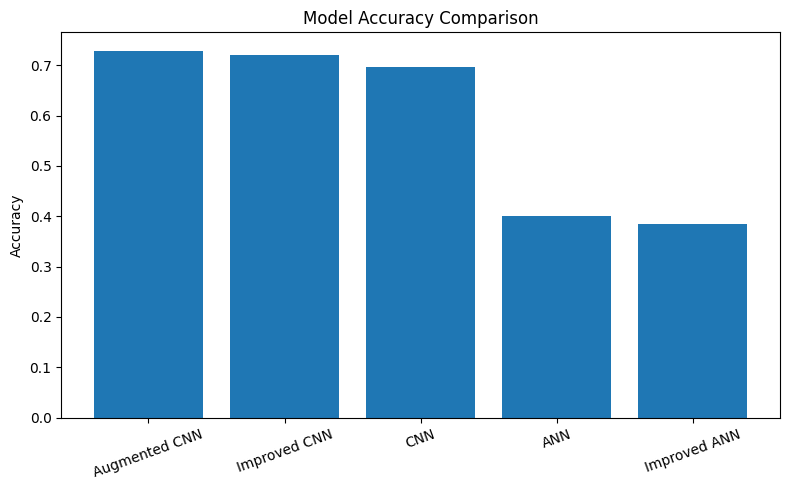

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Conclusion

1. ANN achieved the lowest accuracy because flattening removes spatial information from images.

2. CNN significantly outperformed ANN by learning local image features through convolution operations.

3. Increasing the filter progression from 32→64→128 improved feature extraction and classification performance.

4. Data augmentation improved model generalization and produced the best overall test accuracy.

5. The Augmented CNN achieved the highest test accuracy of 72.91%, demonstrating the effectiveness of augmentation strategies for image classification.